# 1. Environment Setup & Data Loading

## 1.1 Project configuration and global settings

In [1]:
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, learning_curve, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import joblib
from pathlib import Path

In [31]:
def setup_data():
    org_path = "../"
    raw_path = f"{org_path}data/raw/"
    prc_path = f"{org_path}data/processed/"
    eda_path = f"{org_path}outputs/eda/"
    otp_path = f"{org_path}data/models/"
    seed = 42

    print("변수 세팅 완료")
    return org_path, raw_path, prc_path, eda_path, otp_path, seed

# 사용 예시 (반환값 9개)
org_path, raw_path, prc_path, eda_path, otp_path, seed = setup_data()

변수 세팅 완료


In [3]:
def set_display_options():
    pd.set_option('display.max_columns', None)
    pd.set_option('display.max_rows', None)
    pd.set_option('display.float_format', lambda x: '%.3f' % x)
    print("디스플레이 옵션 설정 완료")
set_display_options()

디스플레이 옵션 설정 완료


## 1.2 Loading raw source files (CSV)

In [4]:
def load_multiple_csv_with_schema(
    base_path: str,
    filenames: List[str],
) -> Tuple[Dict[str, pd.DataFrame], List[str], List[str], List[str], List[str], List[str]]:
    """
    여러 CSV 파일을 한 번에 불러오되,
    사전에 정의한 key/cat/int/float/target 타입에 따라 dtype을 지정하여 로딩.

    Returns
    -------
    dataframes : dict[str, pd.DataFrame]
        각 파일명을 key, DataFrame을 value로 하는 딕셔너리
    key_cols : list[str]
    target_cols : list[str]
    cat_cols : list[str]
    int_cols : list[str]
    float_cols : list[str]
    """

    # 1) 변수 그룹 정의
    key_cols = [
        "user_id",
        "session_id",
    ]

    target_cols = [
        "label_repurchase",
    ]

    cat_cols = [
        "session_main_events",
        "session_browser",
        "session_traffic_source",
        "session_state",

        # 시간 start
        "session_start_hour",
        "session_start_weekday",
        "session_start_is_weekend",
        "session_start_day",
        "session_start_week",
        "session_start_month",
        "session_start_quarter",
        "session_start_year",

        # 시간 end
        "session_end_hour",
        "session_end_weekday",
        "session_end_is_weekend",
        "session_end_day",
        "session_end_week",
        "session_end_month",
        "session_end_quarter",
        "session_end_year",

        # 상품 / 사용자
        "product_category",
        "user_gender",
        "user_country",
    ]

    int_cols = [
        "session_event_count",
        "event_type_nunique",
        "user_age",
    ]

    float_cols = [
        "session_duration_hour",
        "total_price",
    ]

    num_cols = int_cols + float_cols

    # 2) dtype 매핑
    dtype_map: dict = {}
    dtype_map.update({col: "string" for col in key_cols})
    dtype_map.update({col: "string" for col in cat_cols})  # 나중에 category 변환
    dtype_map.update({col: "Int64" for col in int_cols + target_cols})
    dtype_map.update({col: "float" for col in float_cols})
    

    # 3) 여러 CSV 로딩
    base = Path(base_path)
    dataframes: Dict[str, pd.DataFrame] = {}

    for name in filenames:
        file_path = base / f"{name}.csv"

        if not file_path.exists():
            print(f"파일 없음: {file_path}")
            continue

        df = pd.read_csv(file_path, dtype=dtype_map)
        dataframes[name] = df
        print(f"{name}.csv 로드 완료 — shape={df.shape}")

    return dataframes, key_cols, target_cols, cat_cols, int_cols, float_cols, num_cols

In [5]:
file_list = [
    "train_df", "test_df"
]

# CSV 로드
dfs, key_cols, target_col, cat_cols, int_cols, float_cols, num_cols = load_multiple_csv_with_schema(
    base_path=prc_path,
    filenames=file_list
)
num_cols = int_cols+float_cols

train_df.csv 로드 완료 — shape=(62509, 31)
test_df.csv 로드 완료 — shape=(15628, 31)


In [6]:
# 변수 자동 생성
for name, df in dfs.items():
    globals()[name] = df
    print(f"테이블 생성 완료: {name} (shape={df.shape})")
del dfs

테이블 생성 완료: train_df (shape=(62509, 31))
테이블 생성 완료: test_df (shape=(15628, 31))


In [7]:
target_col

['label_repurchase']

# 2. 데이터 전처리

## 2.1 train / test set 분리

In [8]:
# 1) train_df
X_train  = train_df.drop(target_col, axis=1)
y_train  = train_df[target_col]

# test_df
X_test = test_df.drop(target_col, axis=1)
y_test = test_df[target_col]

## 2.2 전처리 파이프라인

In [9]:
preprocess = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

In [10]:
# 불균형 가능성을 고려해 StratifiedKFold 사용
cv = StratifiedKFold(
    n_splits=5,          # 필요시 3, 5, 10 등 조정
    shuffle=True,
    random_state=seed
)

# 3. 모델링

In [11]:
print("==== train set ====")
print(y_train.value_counts(normalize=True))
print("==== test set ====")
print(y_test.value_counts(normalize=True))

==== train set ====
label_repurchase
1                  0.563
0                  0.437
Name: proportion, dtype: float64
==== test set ====
label_repurchase
1                  0.563
0                  0.437
Name: proportion, dtype: float64


## 3.1 SVM

In [12]:
# One-Hot 인코딩으로 차원이 커질 수 있어서, RBF SVC보다는 LinearSVC를 우선 사용
# 1) 파이프라인 정의
svm_pipe = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("clf", LinearSVC(random_state=seed))
    ]
)

# 2) 탐색 범위 지정 
# loss 에 따라 dual 제약이 있어서, 리스트 두 개로 나눠서 그리드를 주는 게 안전
svm_param_grid = [
    # 1) loss = hinge (dual=True만 허용)
    {
        "clf__loss": ["hinge"],
        "clf__dual": [True],
        "clf__C": [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
        "clf__class_weight": [None, "balanced"],
    },
    # 2) loss = squared_hinge (dual True/False 모두 허용)
    {
        "clf__loss": ["squared_hinge"],
        "clf__dual": [True, False],
        "clf__C": [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
        "clf__class_weight": [None, "balanced"],
    },
]

svm_search = GridSearchCV(
    estimator=svm_pipe,
    param_grid=svm_param_grid,
    cv=cv,
    scoring="f1",        # 이진 불균형이면 f1 / f1_macro / roc_auc 등 선택
    n_jobs=-1,
    verbose=1
)

# 4) 모델 학습
svm_search.fit(X_train, y_train)

print("=== SVM (LinearSVC) - CV 결과 ===")
print("최적 파라미터:", svm_search.best_params_)
print("CV 최고 점수:", svm_search.best_score_)

# 5) 최적 모델로 test set 평가
best_svm = svm_search.best_estimator_
y_test_pred_svm = best_svm.predict(X_test)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


c:\Users\Owner\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


=== SVM (LinearSVC) - CV 결과 ===
최적 파라미터: {'clf__C': 10.0, 'clf__class_weight': None, 'clf__dual': True, 'clf__loss': 'squared_hinge'}
CV 최고 점수: 0.7365721447050954


c:\Users\Owner\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [13]:
print("=== SVM (LinearSVC) - Test ===")
print("Accuracy:", accuracy_score(y_test, y_test_pred_svm))
print(classification_report(y_test, y_test_pred_svm))

=== SVM (LinearSVC) - Test ===
Accuracy: 0.7326593294087536
              precision    recall  f1-score   support

         0.0       0.64      0.90      0.75      6837
         1.0       0.88      0.60      0.72      8791

    accuracy                           0.73     15628
   macro avg       0.76      0.75      0.73     15628
weighted avg       0.78      0.73      0.73     15628



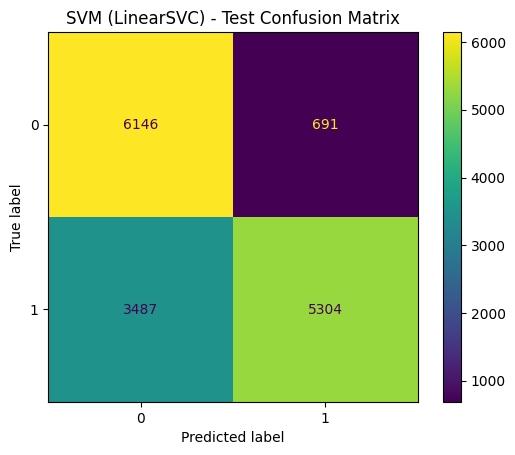

In [14]:
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred_svm)
plt.title("SVM (LinearSVC) - Test Confusion Matrix")
plt.show()

## 3.2 Logistic Regression

In [15]:
# 1) 파이프라인 정의
log_pipe = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("clf", LogisticRegression(
            max_iter=1000,
            n_jobs=-1
        ))
    ]
)

# 2) 탐색 범위 지정 
# solver마다 지원하는 penalty가 다르기 때문에, 여기서도 리스트 두 세트로 나누는 게 깔끔
log_param_grid = [
    # 1) lbfgs 기반 (l2만 가능)
    {
        "clf__solver": ["lbfgs"],
        "clf__penalty": ["l2"],
        "clf__C": [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
        "clf__class_weight": [None, "balanced"],
    },
    # 2) liblinear 기반 (l1, l2 가능)
    {
        "clf__solver": ["liblinear"],
        "clf__penalty": ["l1", "l2"],
        "clf__C": [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
        "clf__class_weight": [None, "balanced"],
    },
    # 3) saga 기반 (elasticnet까지 포함하고 싶을 때)
    {
        "clf__solver": ["saga"],
        "clf__penalty": ["l1", "l2", "elasticnet"],
        "clf__C": [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
        "clf__class_weight": [None, "balanced"],
        "clf__l1_ratio": [0.1, 0.5, 0.9],   # elasticnet일 때만 사용됨
    },
]

# 3) 모델 정의
log_search = GridSearchCV(
    estimator=log_pipe,
    param_grid=log_param_grid,
    cv=cv,
    scoring="f1",    # 동일하게 맞춰줌
    n_jobs=-1,
    verbose=1
)

# 4) 모델 학습
log_search.fit(X_train, y_train)

print("=== Logistic Regression - CV 결과 ===")
print("최적 파라미터:", log_search.best_params_)
print("CV 최고 점수:", log_search.best_score_)


# 5) 최적 모델로 test set 평가
best_log = log_search.best_estimator_
y_test_pred_log = best_log.predict(X_test)

Fitting 5 folds for each of 144 candidates, totalling 720 fits


c:\Users\Owner\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
c:\Users\Owner\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


=== Logistic Regression - CV 결과 ===
최적 파라미터: {'clf__C': 0.001, 'clf__class_weight': None, 'clf__l1_ratio': 0.9, 'clf__penalty': 'l2', 'clf__solver': 'saga'}
CV 최고 점수: 0.7370216766834607


In [16]:
print("=== Logistic Regression - Test ===")
print("Accuracy:", accuracy_score(y_test, y_test_pred_log))
print(classification_report(y_test, y_test_pred_log))

=== Logistic Regression - Test ===
Accuracy: 0.7326593294087536
              precision    recall  f1-score   support

         0.0       0.65      0.86      0.74      6837
         1.0       0.86      0.63      0.73      8791

    accuracy                           0.73     15628
   macro avg       0.75      0.75      0.73     15628
weighted avg       0.76      0.73      0.73     15628



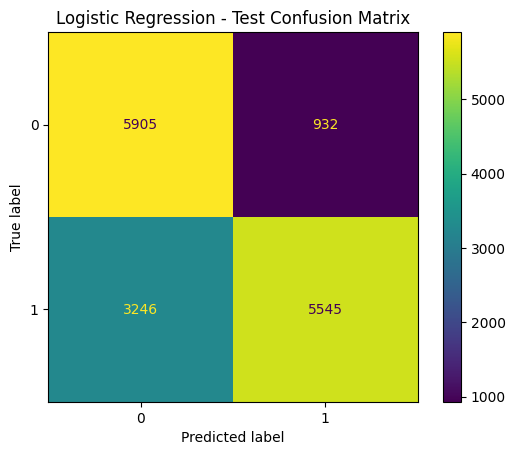

In [17]:
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred_log)
plt.title("Logistic Regression - Test Confusion Matrix")
plt.show()

# 4. 결과 분석

## 4.1 Learning Curve

In [18]:
def plot_learning_curve(model, X, y, title, cv, scoring="f1"):
    train_sizes, train_scores, val_scores = learning_curve(
        model,
        X,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 5),
        shuffle=True,
        random_state=seed,
    )

    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    val_mean = val_scores.mean(axis=1)
    val_std = val_scores.std(axis=1)

    plt.figure(figsize=(8, 6))
    plt.plot(train_sizes, train_mean, 'o-', label="Train F1")
    plt.plot(train_sizes, val_mean, 'o-', label="Validation F1")

    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2)
    plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2)

    plt.title(title)
    plt.xlabel("Training Size")
    plt.ylabel("F1 Score")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

**SVM Learning Curve**

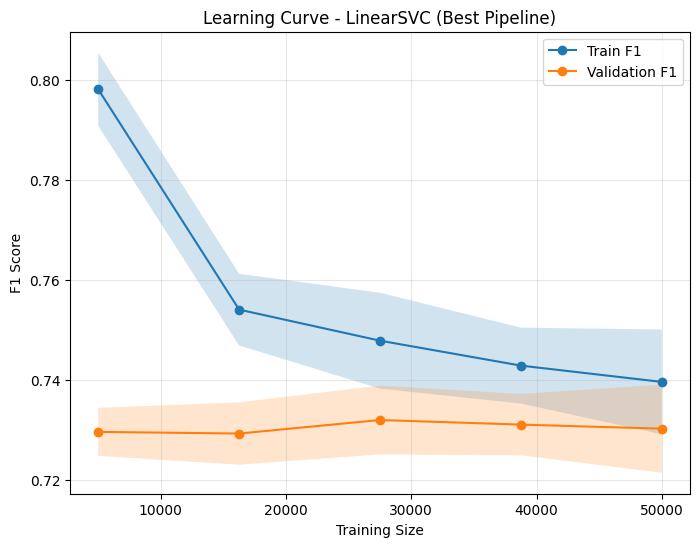

In [19]:
best_svm = svm_search.best_estimator_

plot_learning_curve(
    model=best_svm,
    X=X_train,
    y=y_train,
    title="Learning Curve - LinearSVC (Best Pipeline)",
    cv=cv,
    scoring="f1",
)

**Logistic Regression Learning Curve**

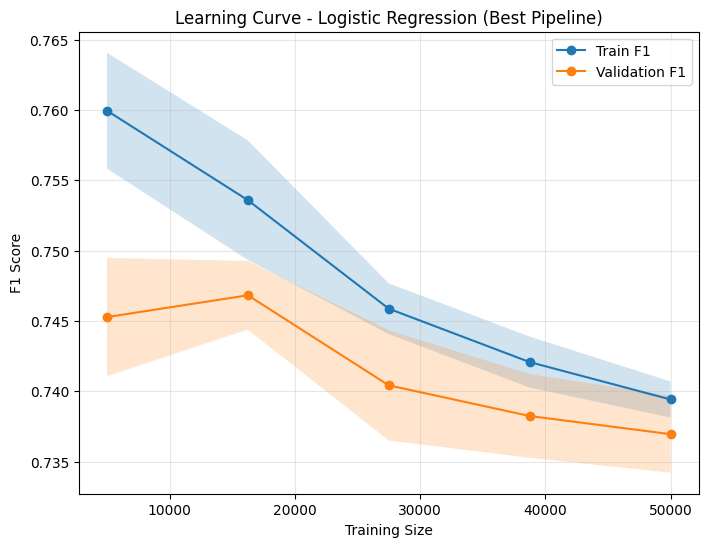

In [20]:
best_log = log_search.best_estimator_

plot_learning_curve(
    model=best_log,
    X=X_train,
    y=y_train,
    title="Learning Curve - Logistic Regression (Best Pipeline)",
    cv=cv,
    scoring="f1",
)

**[결론]**
1. 학습 곡선 해석  
    - train, val 둘 다 0.7대에서 평탄하게 수렴 → 이 피처+모델 조합의 성능 상한이 0.7대 근처
    - 심각한 언더&오버피팅은 아님 → 데이터만 더 늘려서 해결될 문제는 아닐 가능성이 큼
    - 클래스 비율 0.57:0.43 → 불균형 영향은 “보조 요인 수준

2. 수행 우선 순위
    - 1순위: 피처 엔지니어링
      - 도메인 기반 새 변수 추가, 비선형 변환, 상호작용 피처 등으로 정보량 자체를 키우기
    - 2순위: 모델&하이퍼파라미터 조정
      - SVM&로지스틱에서 C, 커널, 특성 스케일링, 규제 강도 등으로 복잡도 조절
    - 3순위: 클래스 비율 관련 조정
      - class_weight, 샘플링은 해볼 가치는 있으나 성능 ceiling을 깨는 메인 수단은 아님

## 4.2 변수 중요도

In [21]:
# 1) 최적 파이프라인에서 전처리 단계 꺼내기
best_log = log_search.best_estimator_
preprocess_fitted = best_log.named_steps["preprocess"]

# 2) 숫자형 feature 이름 (원래 리스트 그대로)
num_feature_names = num_cols

# 3) 범주형 feature 이름 (OneHotEncoder에서 get_feature_names_out)
ohe = preprocess_fitted.named_transformers_["cat"]
cat_feature_names = ohe.get_feature_names_out(cat_cols)

# 4) 전체 feature 이름
all_feature_names = np.concatenate([num_feature_names, cat_feature_names])

**SVM**

In [22]:
# SVM (LinearSVC) 계수 기반 중요도
best_svm = svm_search.best_estimator_
svm_clf_best = best_svm.named_steps["clf"]   # LinearSVC 인스턴스

svm_coefs = svm_clf_best.coef_[0]

svm_importance_df = pd.DataFrame({
    "feature": all_feature_names,
    "coef": svm_coefs,
    "abs_coef": np.abs(svm_coefs),
}).sort_values("abs_coef", ascending=False)

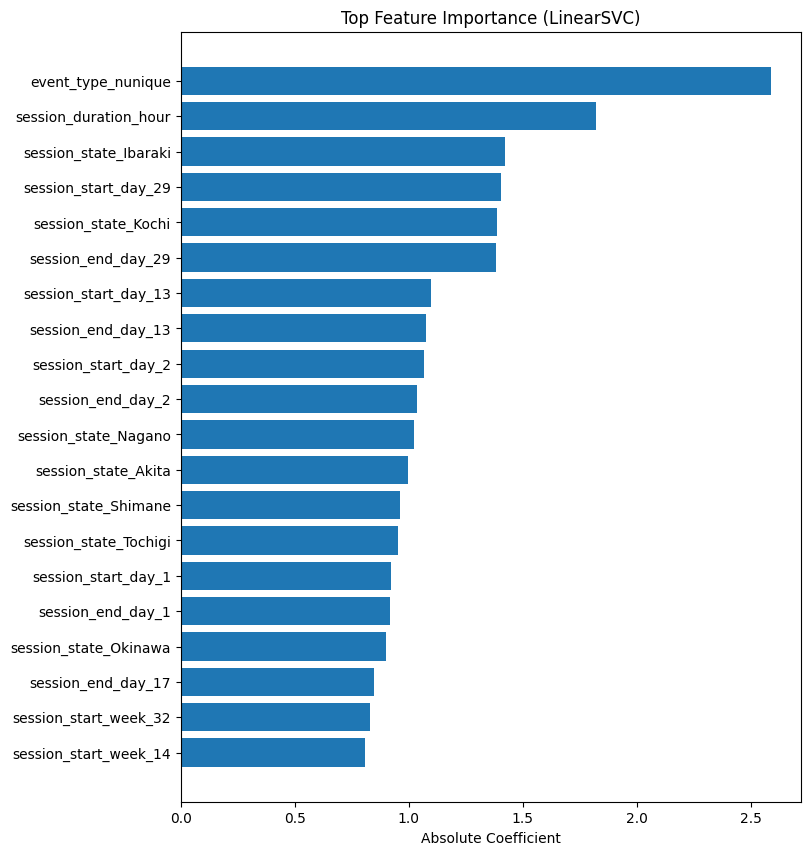

In [23]:
top_n = 20
top_svm = svm_importance_df.head(top_n).sort_values("abs_coef")

plt.figure(figsize=(8, 10))
plt.barh(top_svm["feature"], top_svm["abs_coef"])
plt.title("Top Feature Importance (LinearSVC)")
plt.xlabel("Absolute Coefficient")
plt.show()

**Logistic Regression**

In [24]:
# Logistic Regression 계수 기반 중요도
log_clf_best = best_log.named_steps["clf"]   # LogisticRegression 인스턴스

log_coefs = log_clf_best.coef_[0]

coef_df = pd.DataFrame({
    "feature": all_feature_names,
    "coef": log_coefs,
    "abs_coef": np.abs(log_coefs),
}).sort_values("abs_coef", ascending=False)

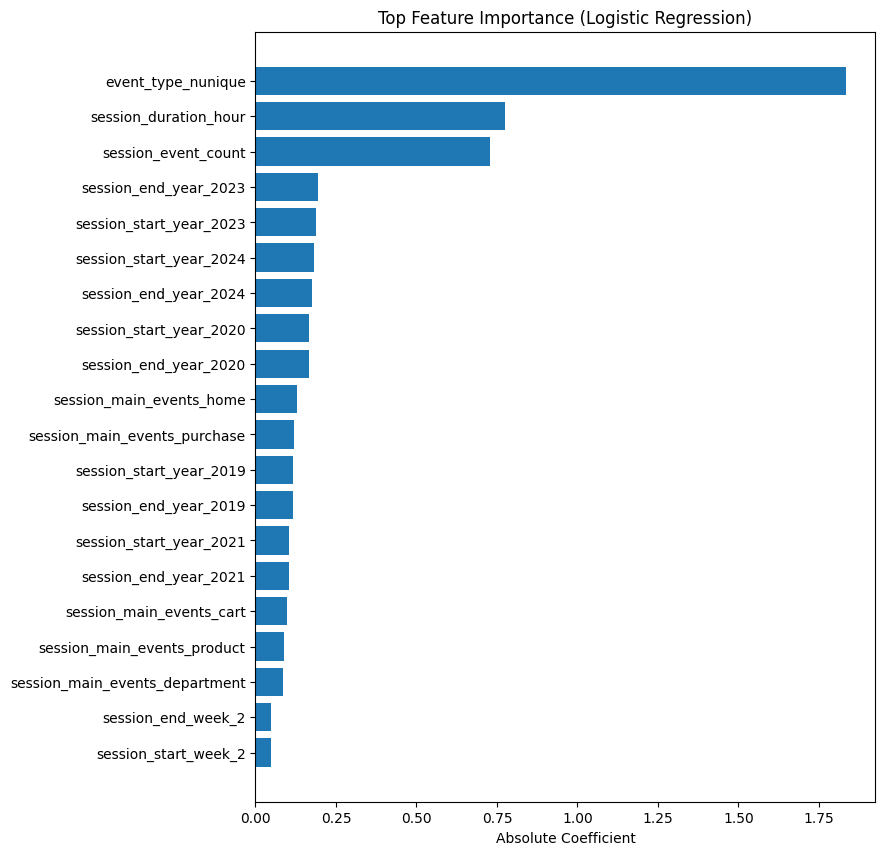

In [25]:
top_n = 20
top_features = coef_df.head(top_n).sort_values("abs_coef")

plt.figure(figsize=(8, 10))
plt.barh(top_features["feature"], top_features["abs_coef"])
plt.title("Top Feature Importance (Logistic Regression)")
plt.xlabel("Absolute Coefficient")
plt.show()

# 5. 모델 저장

In [32]:
# 1) 최종 모델 (Logistic Regression)
joblib.dump(best_log, otp_path + "best_logistic_pipeline.pkl")

# 2) 최종 모델 (SVM)
joblib.dump(best_svm, otp_path + "best_svm_pipeline.pkl")

print("모델 저장 완료")

모델 저장 완료
